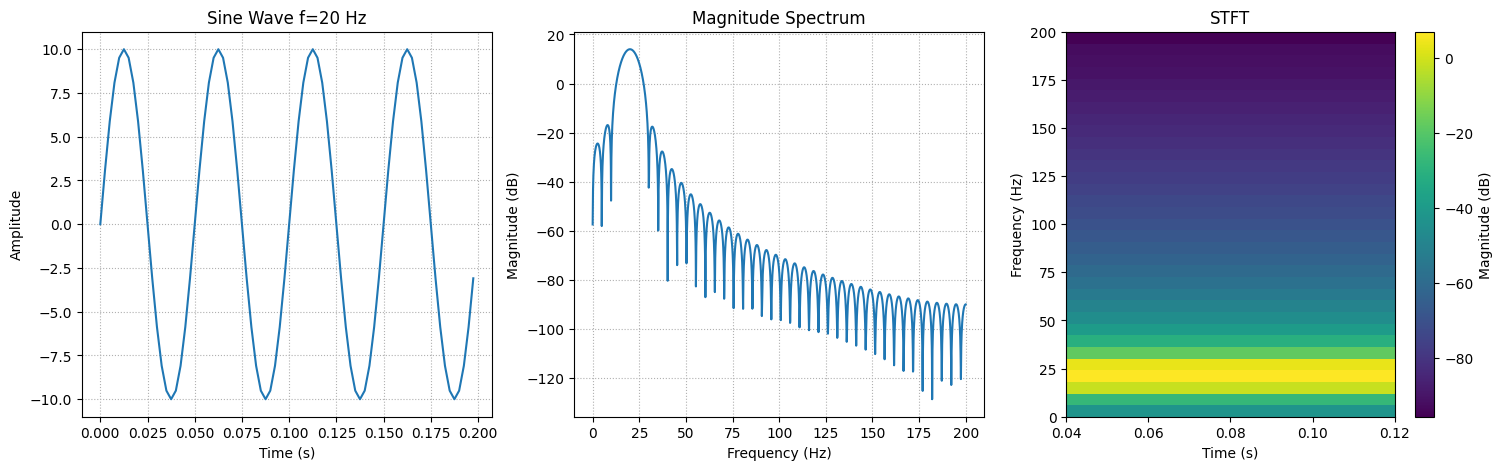

In [34]:
import numpy as np
import matplotlib.pyplot as plt

f = 20  # hz 
T = 1/f # 50ms; 0.05 s
phi = 0

w = 2*np.pi*f

fs = 20*f   # 100 sps
ts = 1/fs  # 10 ms; 0.01 s
n = np.arange(0, 4*T*fs)
t = n*ts

A1 = 10

x1 = A1*np.sin(w*t + phi)

plt.figure(figsize=(18, 5))

plt.subplot(1,3,1)
plt.title('Sine Wave f={} Hz'.format(f))
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.plot(t,x1)
plt.grid(ls=":")

plt.subplot(1,3,2)
plt.title('Magnitude Spectrum')
plt.magnitude_spectrum(x1, Fs=fs, pad_to=4096,  scale='dB')
plt.grid(ls=":")
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
#plt.xticks(np.arange(0, fs/2 + 1, 10))

plt.subplot(1,3,3)
plt.title("STFT")
#plt.specgram(x1, NFFT=4096, Fs=fs, noverlap=128, scale='dB')
Pxx, freqs, bins, im = plt.specgram(x1, NFFT=64, Fs=fs, noverlap=32, scale='dB')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')    
plt.colorbar(im, label='Magnitude (dB)')

plt.show()

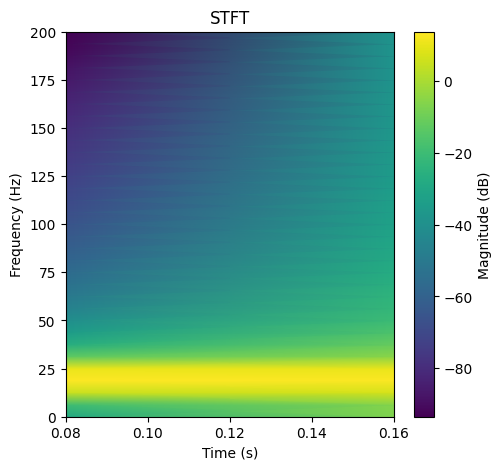

In [36]:
from scipy.signal import stft

# STFT
f, t, Zxx = stft(
    x1,
    fs=fs,
    window='hann',
    nperseg=64,
    noverlap=32,
    nfft=64,
    boundary=None
)

# Magnitud en dB
Zxx_dB = 20 * np.log10(np.abs(Zxx) + 1e-12)

plt.figure(figsize=(18, 5))
plt.subplot(1,3,3)
plt.title("STFT")
plt.pcolormesh(t, f, Zxx_dB, shading='gouraud')
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.colorbar(label="Magnitude (dB)")
plt.ylim(0, fs/2)

plt.show()